# Section 2: Practical Questions (Hands-on using your dataset)

Q6. Data Understanding
Load the dataset
Display first 5 rows
Check:
Shape
Data types
Column names

In [1]:
import numpy as np
import pandas as pd

In [5]:
# Load Dataset
df = pd.read_csv('/content/bank.csv')

# First 5 Rows
print(df.head())

# Shape
print("Shape:", df.shape)

# Data Types
print(df.dtypes)

# Column Names
print(df.columns.tolist())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
Shape: (11162, 17)
age           int64
job          object
marital      object
education    object


# Interpret:
# What types of variables are present?
Rows = Number of Records
Columns = Number of Features

Interpretation
Dataset Shape
Rows = Number of Records
Columns = Number of Features
Data Types

Typically:
Object → Categorical Variables
int64 → Integer Numerical Variables
float64 → Continuous Numerical Variables
Variables Present

Examples:
Numerical Variables
ApplicantIncome
CoapplicantIncome
LoanAmount
Categorical Variables
Gender
Married
Education
Property_Area
Loan_Status

Q7. Data Cleaning
Check for missing values
Handle missing values (if any)
Check for duplicates

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove Duplicates
df = df.drop_duplicates()

print("\nAfter Cleaning")
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())



Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Duplicate Rows:
0

After Cleaning
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
Duplicate Rows: 0


In [7]:
# Q8. Data Preprocessing
# Convert categorical variables into numerical
# Mention which encoding method you used

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
print("\nDataset After Encoding")
display(df.head())



Dataset After Encoding


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [9]:
# Change target column if different
target_column = 'loan'
X = df.drop(target_column, axis=1)
y = df[target_column]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)


X_train Shape: (8929, 16)
X_test Shape: (2233, 16)


In [11]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

In [12]:
# Q13.Pruning Experiment
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score")
print(accuracy)
print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nClassification Report")
print(classification_report(y_test, y_pred))



Accuracy Score
0.8763994626063591

Confusion Matrix
[[1943   17]
 [ 259   14]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1960
           1       0.45      0.05      0.09       273

    accuracy                           0.88      2233
   macro avg       0.67      0.52      0.51      2233
weighted avg       0.83      0.88      0.83      2233



In [13]:
# Q12. OVERFITTING CHECK
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)
print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)
if train_acc - test_acc > 0.10:
    print("Model may be Overfitting")
elif train_acc < 0.70 and test_acc < 0.70:
    print("Model may be Underfitting")
else:
    print("Model is Balanced")



Training Accuracy: 0.870870198230485
Testing Accuracy: 0.8763994626063591
Model is Balanced


In [14]:
# Q13. PRUNING EXPERIMENT
pruned_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)
pruned_model.fit(X_train, y_train)
pruned_pred = pruned_model.predict(X_test)
pruned_accuracy = accuracy_score(
    y_test,
    pruned_pred
)
print("\nPruned Model Accuracy")
print(pruned_accuracy)
print("\nOriginal Model Accuracy")
print(accuracy)



Pruned Model Accuracy
0.877295118674429

Original Model Accuracy
0.8763994626063591



Top 5 Important Features
     Feature  Importance
5    balance    0.324409
9      month    0.182002
15   deposit    0.127113
10  duration    0.106609
6    housing    0.066300


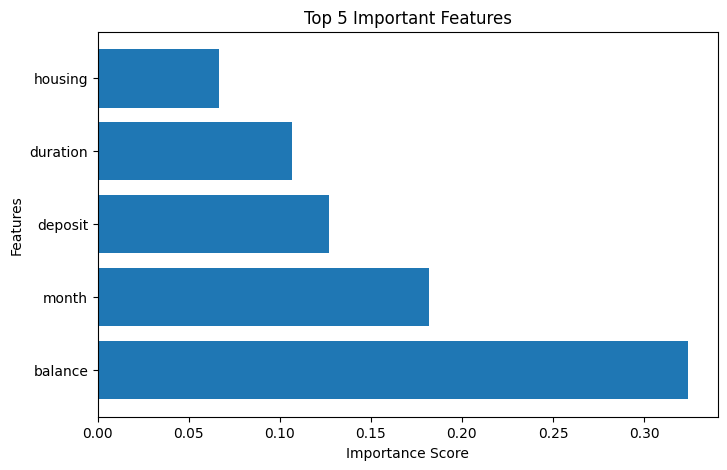

In [15]:
# Q14. FEATURE IMPORTANCE
import matplotlib.pyplot as plt
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print("\nTop 5 Important Features")
print(feature_importance.head())
top5 = feature_importance.head(5)
plt.figure(figsize=(8,5))
plt.barh(
    top5['Feature'],
    top5['Importance']
)
plt.title('Top 5 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


Q15 Business Insight ::
Customers More Likely To Say "Yes"
Customers having good credit history
Customers with stable income
Customers requiring moderate loan amount
Customers matching the top important features identified by the model

Bank Strategy:

Focus marketing campaigns on high-probability customers
Offer personalized loan products
Reduce marketing cost by targeting likely customers
Use feature importance insights for better decision making
Improve loan conversion rates